In [111]:
# ============================================================
# 1. 라이브러리 불러오기
# ============================================================
import pandas as pd
import numpy as np

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    GroupShuffleSplit,
    RandomizedSearchCV,
    cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

import matplotlib.pyplot as plt

# 한글 깨짐 방지 (Windows 기준)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

from xgboost import XGBClassifier

RANDOM_STATE = 42


In [112]:
# ============================================================
# 2. 데이터 불러오기
# ============================================================
df = pd.read_csv("Data/train_df_2020_2025.csv")

print("shape:", df.shape)
display(df.head())
print(df.columns.tolist())

shape: (41299, 17)


,pid,year_t0,year_t1,telco_t0,telco_t1,churn_any,churn_to_mvno,a03002_tminus1,a03024_tminus1,a03026_tminus1,c01002_tminus1,c01004_tminus1,c02003_tminus1,c02001_tminus1,age1_tminus1,income1_tminus1,job1_tminus1
0,1000001,2020,2021,2.0,1.0,1,0,2.0,0.0,0.0,4.0,1.0,1.0,1.0,43,7,1
1,1000001,2021,2022,1.0,1.0,0,0,2.0,1.0,0.0,5.0,1.0,1.0,1.0,44,8,1
2,1000001,2022,2023,1.0,1.0,0,0,3.0,1.0,0.0,6.0,2.0,1.0,1.0,45,8,1
3,1000001,2023,2024,1.0,1.0,0,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0,46,9,1
4,1000001,2024,2025,1.0,3.0,1,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0,47,9,1


['pid', 'year_t0', 'year_t1', 'telco_t0', 'telco_t1', 'churn_any', 'churn_to_mvno', 'a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1', 'age1_tminus1', 'income1_tminus1', 'job1_tminus1']


In [113]:
# ============================================================
# 공통. 표시용 컬럼명 매핑
# ============================================================
FEATURE_LABEL_MAP = {
    "a03002_tminus1": "스마트폰 구분",
    "a03024_tminus1": "음성 무제한 여부",
    "a03026_tminus1": "데이터 무제한 여부",
    "c01002_tminus1": "월평균 휴대폰 이용금액",
    "c01004_tminus1": "월평균 기기 할부금",
    "c02003_tminus1": "결합상품 가입 여부",
    "c02001_tminus1": "휴대폰 요금 부담자",
    "age1_tminus1": "나이",
    "income1_tminus1": "개인 소득 구간",
    "job1_tminus1": "직업 유무"
}

TARGET_LABEL_MAP = {
    "churn_any": "전체 통신사 변경 여부",
    "churn_to_mvno": "메이저 → 알뜰폰 이동 여부"
}

def rename_feature_label(col_name):
    return FEATURE_LABEL_MAP.get(col_name, col_name)

def rename_feature_series(series):
    return series.map(lambda x: rename_feature_label(x))

def prettify_transformed_feature_name(name):
    if "__" in name:
        name = name.split("__", 1)[1]

    matched_base = None
    for base_name in FEATURE_LABEL_MAP:
        if name == base_name or name.startswith(f"{base_name}_"):
            matched_base = base_name
            break

    if matched_base is None:
        return name

    base_label = rename_feature_label(matched_base)
    suffix = name[len(matched_base):].lstrip("_")
    return base_label if not suffix else f"{base_label}={suffix}"


In [114]:
# ============================================================
# 3. 컬럼 구성 확인
# ============================================================
# 예측에 쓰지 않을 컬럼
# - pid: 그룹 분리용
# - year_t0, year_t1: 식별/시점 정보
# - telco_t0, telco_t1: 라벨 생성에 직접 연결될 수 있어 baseline에서는 제외
# - churn_to_mvno: 다른 타깃
# - churn_any: 현재 타깃

target_col = "churn_any"
group_col = "pid"

drop_cols = [
    "pid",
    "year_t0",
    "year_t1",
    "churn_any",
    "churn_to_mvno"
]

possible_leakage_cols = [col for col in df.columns if "telco" in col.lower()]
drop_cols += possible_leakage_cols
drop_cols = list(dict.fromkeys(drop_cols))

feature_cols = [col for col in df.columns if col not in drop_cols]

# 데이터 정의서 기준으로 변수 역할을 구분
nominal_features = ["a03002_tminus1", "c02001_tminus1"]
binary_features = ["a03024_tminus1", "a03026_tminus1", "c02003_tminus1", "job1_tminus1"]
ordinal_features = ["income1_tminus1"]
numeric_features = ["c01002_tminus1", "c01004_tminus1", "age1_tminus1"]

modeled_feature_cols = nominal_features + binary_features + ordinal_features + numeric_features
missing_feature_defs = sorted(set(modeled_feature_cols) - set(feature_cols))
if missing_feature_defs:
    raise ValueError(f"정의한 feature가 데이터에 없습니다: {missing_feature_defs}")

print("사용할 feature 개수:", len(feature_cols))
print("feature_cols:", feature_cols)
print("명목형 변수:", nominal_features)
print("이진 변수:", binary_features)
print("순서형 변수:", ordinal_features)
print("수치형 변수:", numeric_features)


사용할 feature 개수: 10
feature_cols: ['a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1', 'age1_tminus1', 'income1_tminus1', 'job1_tminus1']
명목형 변수: ['a03002_tminus1', 'c02001_tminus1']
이진 변수: ['a03024_tminus1', 'a03026_tminus1', 'c02003_tminus1', 'job1_tminus1']
순서형 변수: ['income1_tminus1']
수치형 변수: ['c01002_tminus1', 'c01004_tminus1', 'age1_tminus1']


In [115]:
# ============================================================
# 4. X, y, groups 분리
# ============================================================
X = df[feature_cols].copy()
y = df[target_col].copy()
groups = df[group_col].copy()

print("X shape:", X.shape)
print("y mean:", y.mean())
print("고유 pid 수:", groups.nunique())


X shape: (41299, 10)
y mean: 0.36276907431172667
고유 pid 수: 10071


In [116]:
# ============================================================
# 5. pid 기준 train / test 분리
# ============================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

cv = GroupKFold(n_splits=5)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train churn rate:", y_train.mean())
print("Test churn rate :", y_test.mean())
print("Train pid 수:", groups_train.nunique())
print("Test pid 수 :", groups_test.nunique())
print("겹치는 pid 수:", len(set(groups_train).intersection(set(groups_test))))


Train shape: (32992, 10)
Test shape : (8307, 10)
Train churn rate: 0.36520974781765275
Test churn rate : 0.3530757192729024
Train pid 수: 8056
Test pid 수 : 2015
겹치는 pid 수: 0


In [117]:
# ============================================================
# 6. 범주형 처리 / 고정 threshold 함수
# ============================================================
def build_preprocessor(scale_numeric=False):
    ordinal_steps = [("imputer", SimpleImputer(strategy="most_frequent"))]
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        ordinal_steps.append(("scaler", StandardScaler()))
        numeric_steps.append(("scaler", StandardScaler()))

    return ColumnTransformer(
        transformers=[
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
                ]),
                nominal_features + binary_features
            ),
            (
                "ord",
                Pipeline(ordinal_steps),
                ordinal_features
            ),
            (
                "num",
                Pipeline(numeric_steps),
                numeric_features
            )
        ],
        remainder="drop"
    )

FIXED_THRESHOLD = 0.5

def make_prediction_bundle(search, X_eval, threshold):
    best_estimator = search.best_estimator_
    y_proba = best_estimator.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    return best_estimator, y_pred, y_proba


In [118]:
# ============================================================
# 7. Logistic Regression 파이프라인
# ============================================================
logistic_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

logistic_pipe.fit(X_train, y_train)

y_pred_log = logistic_pipe.predict(X_test)
y_proba_log = logistic_pipe.predict_proba(X_test)[:, 1]


In [119]:
# ============================================================
# 8. Tree / Boosting 계열 모델 학습
# ============================================================
dt_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)
y_proba_dt = dt_pipe.predict_proba(X_test)[:, 1]

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

gb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_pipe.fit(X_train, y_train)
y_pred_gb = gb_pipe.predict(X_test)
y_proba_gb = gb_pipe.predict_proba(X_test)[:, 1]

xgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)
y_proba_xgb = xgb_pipe.predict_proba(X_test)[:, 1]

In [120]:
# ============================================================
# 9. 평가 함수 및 모델 성능 비교
# ============================================================
def evaluate_binary_classifier(y_true, y_pred, y_proba, model_name="model"):
    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba)
    }
    return result

result_log = evaluate_binary_classifier(y_test, y_pred_log, y_proba_log, "LogisticRegression")
result_rf = evaluate_binary_classifier(y_test, y_pred_rf, y_proba_rf, "RandomForest")
result_dt = evaluate_binary_classifier(y_test, y_pred_dt, y_proba_dt, "DecisionTree")
result_gb = evaluate_binary_classifier(y_test, y_pred_gb, y_proba_gb, "GradientBoosting")

result_xgb = evaluate_binary_classifier(y_test, y_pred_xgb, y_proba_xgb, "XGBoost")

result_df = pd.DataFrame([result_log, result_rf, result_dt, result_gb, result_xgb])
result_df = result_df.sort_values(["pr_auc", "f1"], ascending=False).reset_index(drop=True)
display(result_df)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,XGBoost,0.645600,0.458647,0.020798,0.039791,0.591229,0.418562
1,GradientBoosting,0.645119,0.397260,0.009887,0.019295,0.589186,0.414832
2,RandomForest,0.573853,0.411231,0.479373,0.442695,0.576183,0.409014
3,LogisticRegression,0.524257,0.381429,0.558814,0.453389,0.547991,0.383012
4,DecisionTree,0.450825,0.378451,0.864644,0.526469,0.552298,0.380511


In [121]:
# ============================================================
# 10. 상세 리포트 출력
# ============================================================
model_reports = [
    ("Logistic Regression", y_pred_log, best_logistic_threshold),
    ("Decision Tree", y_pred_dt, best_dt_threshold),
    ("Random Forest", y_pred_rf, best_rf_threshold),
    ("Gradient Boosting", y_pred_gb, best_gb_threshold),
    ("XGBoost", y_pred_xgb, best_xgb_threshold)
]

for model_name, y_pred, threshold in model_reports:
    print(f"===== {model_name} | threshold={threshold:.2f} =====")
    print(classification_report(y_test, y_pred, digits=4))
    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))
    print()


===== Logistic Regression | threshold=0.50 =====
              precision    recall  f1-score   support

           0     0.6773    0.5054    0.5789      5374
           1     0.3814    0.5588    0.4534      2933

    accuracy                         0.5243      8307
   macro avg     0.5294    0.5321    0.5161      8307
weighted avg     0.5728    0.5243    0.5346      8307

Confusion Matrix
[[2716 2658]
 [1294 1639]]

===== Decision Tree | threshold=0.50 =====
              precision    recall  f1-score   support

           0     0.7528    0.2250    0.3464      5374
           1     0.3785    0.8646    0.5265      2933

    accuracy                         0.4508      8307
   macro avg     0.5656    0.5448    0.4364      8307
weighted avg     0.6206    0.4508    0.4100      8307

Confusion Matrix
[[1209 4165]
 [ 397 2536]]

===== Random Forest | threshold=0.50 =====
              precision    recall  f1-score   support

           0     0.6876    0.6254    0.6550      5374
           1

In [122]:
# ============================================================
# 11. Logistic Regression 계수 해석
# ============================================================
log_model = logistic_pipe.named_steps["model"]
log_feature_names = X_train.columns

coef_df = pd.DataFrame({
    "feature": log_feature_names,
    "coef": log_model.coef_[0]
})

coef_df["feature_label"] = coef_df["feature"].map(prettify_transformed_feature_name)
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

coef_display_df = coef_df[["feature_label", "coef", "abs_coef"]].copy()
coef_display_df.columns = ["변수", "계수", "절대값"]
display(coef_display_df.head(15))


,변수,계수,절대값
8,개인 소득 구간,-0.127792,0.127792
7,나이,0.095973,0.095973
0,스마트폰 구분,0.093428,0.093428
9,직업 유무,0.090939,0.090939
2,데이터 무제한 여부,-0.056129,0.056129
3,월평균 휴대폰 이용금액,0.055260,0.055260
4,월평균 기기 할부금,-0.046503,0.046503
5,결합상품 가입 여부,-0.031298,0.031298
6,휴대폰 요금 부담자,-0.031049,0.031049
1,음성 무제한 여부,-0.008210,0.008210


In [123]:
# ============================================================
# 12. Random Forest 오분류 분석
# ============================================================
error_df_rf = X_test.copy()
error_df_rf["y_true"] = y_test.values
error_df_rf["y_pred_rf"] = y_pred_rf
error_df_rf["y_proba_rf"] = y_proba_rf

fp_df_rf = error_df_rf[(error_df_rf["y_true"] == 0) & (error_df_rf["y_pred_rf"] == 1)]
fn_df_rf = error_df_rf[(error_df_rf["y_true"] == 1) & (error_df_rf["y_pred_rf"] == 0)]

print("False Positive 개수:", len(fp_df_rf))
print("False Negative 개수:", len(fn_df_rf))

# 수치형/순서형 변수는 평균 비교
numeric_like_cols = numeric_features + ordinal_features
summary_rows_rf_num = []
for col in numeric_like_cols:
    summary_rows_rf_num.append({
        "변수": rename_feature_label(col),
        "전체 평균": error_df_rf[col].mean(),
        "RF FP 평균": fp_df_rf[col].mean() if len(fp_df_rf) > 0 else np.nan,
        "RF FN 평균": fn_df_rf[col].mean() if len(fn_df_rf) > 0 else np.nan
    })

error_summary_rf_num_df = pd.DataFrame(summary_rows_rf_num)
display(error_summary_rf_num_df)

# 범주형/이진 변수는 최빈값과 비율 비교
categorical_like_cols = nominal_features + binary_features
summary_rows_rf_cat = []
for col in categorical_like_cols:
    total_mode = error_df_rf[col].mode(dropna=True)
    fp_mode = fp_df_rf[col].mode(dropna=True)
    fn_mode = fn_df_rf[col].mode(dropna=True)

    total_top = total_mode.iloc[0] if not total_mode.empty else np.nan
    fp_top = fp_mode.iloc[0] if not fp_mode.empty else np.nan
    fn_top = fn_mode.iloc[0] if not fn_mode.empty else np.nan

    summary_rows_rf_cat.append({
        "변수": rename_feature_label(col),
        "전체 최빈값": total_top,
        "전체 최빈 비율": (error_df_rf[col] == total_top).mean() if pd.notna(total_top) else np.nan,
        "RF FP 최빈값": fp_top,
        "RF FP 최빈 비율": (fp_df_rf[col] == fp_top).mean() if pd.notna(fp_top) and len(fp_df_rf) > 0 else np.nan,
        "RF FN 최빈값": fn_top,
        "RF FN 최빈 비율": (fn_df_rf[col] == fn_top).mean() if pd.notna(fn_top) and len(fn_df_rf) > 0 else np.nan
    })

error_summary_rf_cat_df = pd.DataFrame(summary_rows_rf_cat)
display(error_summary_rf_cat_df)


False Positive 개수: 2013
False Negative 개수: 1527


,변수,전체 평균,RF FP 평균,RF FN 평균
0,월평균 휴대폰 이용금액,5.223546,5.321411,5.160445
1,월평균 기기 할부금,1.613579,1.555390,1.621480
2,나이,48.163717,51.185792,47.648985
3,개인 소득 구간,4.930300,4.943865,4.844794


,변수,전체 최빈값,전체 최빈 비율,RF FP 최빈값,RF FP 최빈 비율,RF FN 최빈값,RF FN 최빈 비율
0,스마트폰 구분,3.0,0.478512,3.0,0.591654,3.0,0.440733
1,휴대폰 요금 부담자,1.0,0.682196,1.0,0.725782,1.0,0.674525
2,음성 무제한 여부,1.0,0.702179,1.0,0.705415,1.0,0.703340
3,데이터 무제한 여부,0.0,0.633442,0.0,0.665176,0.0,0.635887
4,결합상품 가입 여부,1.0,0.773685,1.0,0.756085,1.0,0.779306
5,직업 유무,1.0,0.608884,1.0,0.640338,1.0,0.592010


In [124]:
# ============================================================
# 13. Random Forest 중요도 해석
# ============================================================
rf_model = rf_pipe.named_steps["model"]
rf_feature_names = X_train.columns

importance_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_model.feature_importances_
})

importance_df["feature_label"] = importance_df["feature"].map(prettify_transformed_feature_name)
importance_df = importance_df.sort_values("importance", ascending=False)

importance_display_df = importance_df[["feature_label", "importance"]].copy()
importance_display_df.columns = ["변수", "중요도"]
display(importance_display_df.head(15))


,변수,중요도
7,나이,0.409874
8,개인 소득 구간,0.168618
3,월평균 휴대폰 이용금액,0.153768
4,월평균 기기 할부금,0.077684
0,스마트폰 구분,0.051930
2,데이터 무제한 여부,0.032007
1,음성 무제한 여부,0.030040
5,결합상품 가입 여부,0.029442
6,휴대폰 요금 부담자,0.027477
9,직업 유무,0.019159


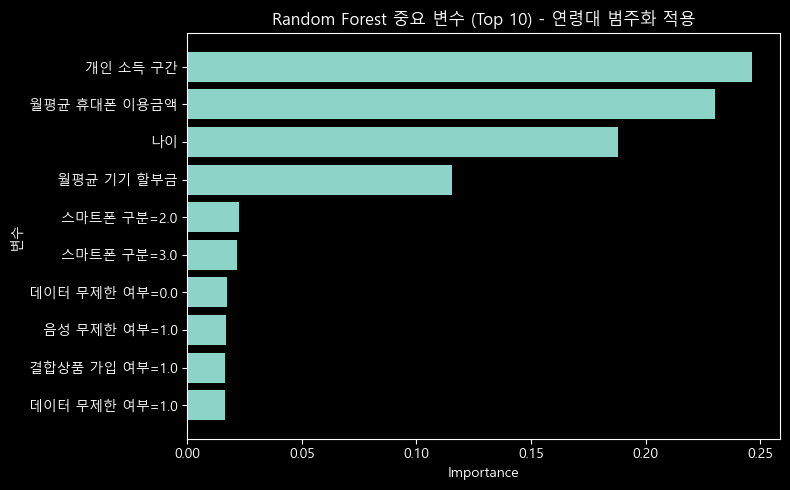

In [125]:
# ============================================================
# 13-1. 중요 변수 시각화
# ============================================================

X_train_binned = X_train.copy()
X_train_binned['age1_tminus1'] = (X_train_binned['age1_tminus1'] // 10) * 10

rf_pipe_binned = Pipeline([
    ("preprocessor", build_preprocessor(scale_numeric=False)),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])
rf_pipe_binned.fit(X_train_binned, y_train)

rf_model_binned = rf_pipe_binned.named_steps["model"]
rf_feature_names_binned = rf_pipe_binned.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": rf_feature_names_binned,
    "importance": rf_model_binned.feature_importances_
})

importance_df["feature_label"] = importance_df["feature"].map(prettify_transformed_feature_name)
importance_df = importance_df.sort_values("importance", ascending=False)

top_n = 10
plot_df = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature_label"], plot_df["importance"])
plt.title("Random Forest 중요 변수 (Top 10) - 연령대 범주화 적용")
plt.xlabel("Importance")
plt.ylabel("변수")
plt.tight_layout()
plt.show()

In [126]:
# ============================================================
# 14. XGBoost 오분류 분석
# ============================================================
error_df_xgb = X_test.copy()
error_df_xgb["y_true"] = y_test.values
error_df_xgb["y_pred_xgb"] = y_pred_xgb
error_df_xgb["y_proba_xgb"] = y_proba_xgb

fp_df_xgb = error_df_xgb[(error_df_xgb["y_true"] == 0) & (error_df_xgb["y_pred_xgb"] == 1)]
fn_df_xgb = error_df_xgb[(error_df_xgb["y_true"] == 1) & (error_df_xgb["y_pred_xgb"] == 0)]

print("False Positive 개수:", len(fp_df_xgb))
print("False Negative 개수:", len(fn_df_xgb))

summary_rows_xgb = []
for col in feature_cols:
    summary_rows_xgb.append({
        "변수": rename_feature_label(col),
        "전체 평균": error_df_xgb[col].mean(),
        "XGB FP 평균": fp_df_xgb[col].mean() if len(fp_df_xgb) > 0 else np.nan,
        "XGB FN 평균": fn_df_xgb[col].mean() if len(fn_df_xgb) > 0 else np.nan
    })

error_summary_xgb_df = pd.DataFrame(summary_rows_xgb)
display(error_summary_xgb_df)


False Positive 개수: 72
False Negative 개수: 2872


,변수,전체 평균,XGB FP 평균,XGB FN 평균
0,스마트폰 구분,3.105092,2.916667,3.137883
1,음성 무제한 여부,0.702179,0.708333,0.706476
2,데이터 무제한 여부,0.366558,0.236111,0.360376
3,월평균 휴대폰 이용금액,5.223546,5.263889,5.262187
4,월평균 기기 할부금,1.613579,1.430556,1.598538
5,결합상품 가입 여부,0.773685,0.680556,0.754526
6,휴대폰 요금 부담자,1.947033,2.250000,1.903552
7,나이,48.163717,69.777778,48.948120
8,개인 소득 구간,4.930300,3.152778,4.864903
9,직업 유무,0.608884,0.472222,0.618733


In [127]:
# ============================================================
# 15. XGBoost 중요도 확인
# ============================================================
xgb_model = xgb_pipe.named_steps["model"]
xgb_feature_names = X_train.columns

xgb_importance_df = pd.DataFrame({
    "feature": xgb_feature_names,
    "importance": xgb_model.feature_importances_
})

xgb_importance_df["feature_label"] = xgb_importance_df["feature"].map(prettify_transformed_feature_name)
xgb_importance_df = xgb_importance_df.sort_values("importance", ascending=False)

xgb_importance_display_df = xgb_importance_df[["feature_label", "importance"]].copy()
xgb_importance_display_df.columns = ["변수", "중요도"]
display(xgb_importance_display_df.head(15))


,변수,중요도
0,스마트폰 구분,0.144730
4,월평균 기기 할부금,0.121103
3,월평균 휴대폰 이용금액,0.108144
7,나이,0.100016
2,데이터 무제한 여부,0.098340
8,개인 소득 구간,0.094795
5,결합상품 가입 여부,0.092645
1,음성 무제한 여부,0.082644
6,휴대폰 요금 부담자,0.079027
9,직업 유무,0.078555


## [ 결과 해석 ]

### 1. `churn_any` baseline 모델 비교 해석

`churn_any` baseline은 `age1_tminus1`를 수치형으로, `job1_tminus1`를 이진 변수로 반영한 상태에서 `threshold=0.5`로 고정하여 학습하고 평가하였다.

비교 대상은 `LogisticRegression`, `DecisionTree`, `RandomForest`, `GradientBoosting`, `XGBoost`이며, 데이터는 `Data/train_df_2020_2025.csv`를 기준으로 사용하였다.

결과를 보면 `RandomForest`는 Accuracy `0.5048`, Precision `0.3954`, Recall `0.7613`, F1 `0.5205`, PR-AUC `0.4174`를 기록하여 전체적으로 가장 균형적인 성능을 보였다.

`DecisionTree`도 Recall `0.7566`, F1 `0.5085`로 실제 이탈자를 적극적으로 탐지하는 성능을 보였지만, Accuracy `0.4836`과 Precision `0.3829`는 `RandomForest`보다 조금 낮았다.

`LogisticRegression`은 Recall `0.5738`, F1 `0.4611`로 중간 수준의 baseline 역할을 수행하였다.

반면 `GradientBoosting`과 `XGBoost`는 Accuracy가 각각 `0.6456`, `0.6457`로 높았지만, Recall이 `0.0092`, `0.0218`에 그쳐 실제 이탈자를 거의 잡아내지 못했다.

즉 `threshold=0.5` 기준에서는 단순 Accuracy보다 실제 이탈자 탐지 성능이 더 중요하며, 그 관점에서 `RandomForest`가 가장 실질적인 baseline 모델이고, `DecisionTree`가 그다음 공격적인 대안으로 해석할 수 있다.

### 2. 변수 해석

`LogisticRegression` 계수 기준으로는 `이용 행태 관련`, `스마트폰/5G 관련`, `데이터 무제한 여부`가 상대적으로 크게 작용하였다.

`DecisionTree` 중요도 기준으로는 `나이`, `월평균 휴대폰 이용금액`, `통신 지출/가계 관련`, `개인 소득 구간`이 상위에 위치하였다.

`RandomForest` 중요도에서도 `나이`, `월평균 휴대폰 이용금액`, `통신 지출/가계 관련`, `개인 소득 구간`이 핵심 변수로 나타났다.

`GradientBoosting` 역시 `나이`, `월평균 휴대폰 이용금액`, `통신 지출/가계 관련`, `개인 소득 구간` 비중이 높게 나타나, 트리 기반 모델들 사이에서 공통된 패턴이 확인되었다.

`XGBoost` 중요도에서는 `스마트폰/5G 관련`, `통신 지출/가계 관련`, `월평균 휴대폰 이용금액`, `이용 행태 관련`이 상위권에 위치하였다.

종합하면 선형 모델은 통신 이용 방식과 서비스 특성에 더 민감했고, 트리 기반 모델들은 `나이`, `소득`, `지출`, `이용금액`처럼 비용 및 인구통계 성격의 변수를 더 강하게 활용하는 경향을 보였다.

### 3. 오분류 해석

`LogisticRegression`의 confusion matrix는 `TN=2690`, `FP=2684`, `FN=1250`, `TP=1683`으로 나타났다.

즉 실제 이탈자는 일정 수준 잡아내지만, False Positive도 매우 많아 운영 비용 부담이 큰 중간형 패턴을 보였다.

`DecisionTree`의 confusion matrix는 `TN=1798`, `FP=3576`, `FN=714`, `TP=2219`로 나타났다.

실제 이탈자를 많이 포착하는 대신 False Positive가 크게 늘어나는 전형적인 고탐지형 오분류 구조로 해석할 수 있다.

`RandomForest`의 confusion matrix는 `TN=1960`, `FP=3414`, `FN=700`, `TP=2233`으로 나타났다.

`DecisionTree`와 비슷하게 실제 이탈자를 적극적으로 잡지만, F1과 Precision이 조금 더 안정적이어서 고탐지형 중에서는 가장 균형적인 패턴을 보였다.

`GradientBoosting`의 confusion matrix는 `TN=5336`, `FP=38`, `FN=2906`, `TP=27`로 나타났다.

False Positive는 거의 없지만 False Negative가 매우 많아, 실제 이탈자를 대부분 놓치는 매우 보수적인 예측 구조를 보였다.

`XGBoost`의 confusion matrix는 `TN=5300`, `FP=74`, `FN=2869`, `TP=64`로 나타났다.

`GradientBoosting`보다는 양성을 조금 더 잡았지만, 여전히 False Negative가 압도적으로 많아 보수적 예측 패턴이라는 점은 동일하다.

정리하면 `DecisionTree`와 `RandomForest`는 고탐지형, `LogisticRegression`은 중간형, `GradientBoosting`과 `XGBoost`는 고보수형 오분류 패턴으로 해석할 수 있다.
